# Упражнения <a id='tasks'></a>

1. Взять  [датасет отсюда](https://www.timeseriesclassification.com/dataset.php). Можно взять разные наборы для классификации/регрессии (но причину надо будет обосновать)

2. Отрисовать данные

3. Попробовать все методы классификации и регрессии, описанные в блоноте:
    Distance-based 
    Свертки (модели семейства Rocket и Hydra)
    Feature-based
    Deep Learning

    Для каждого подхода обучть не менее 3х разных моделей для классификации и регрессии.
    
     
    

In [1]:
from aeon.datasets import load_classification
X, y, meta_data = load_classification("GunPoint", return_metadata=True)
print(" Shape of X = ", X.shape)
print(" Meta data = ", meta_data)

 Shape of X =  (200, 1, 150)
 Meta data =  {'problemname': 'gunpoint', 'timestamps': False, 'missing': False, 'univariate': True, 'equallength': True, 'classlabel': True, 'targetlabel': False, 'class_values': ['1', '2']}


/var/folders/sg/v2cqq27s14zg8lnnhtvkr1b40000gn/T/ipykernel_13258/472478544.py:2: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X, y, meta_data = load_classification("GunPoint", return_metadata=True)


In [5]:
X

array([[[-0.6478854 , -0.64199155, -0.63818632, ..., -0.64042873,
         -0.63866571, -0.63865722]],

       [[-0.64442658, -0.64540093, -0.64705511, ..., -0.6349345 ,
         -0.6344968 , -0.63159565]],

       [[-0.77835282, -0.77827907, -0.77715084, ..., -0.70419626,
         -0.70760524, -0.7071202 ]],

       ...,

       [[-0.73801219, -0.73630065, -0.73122561, ..., -0.60964613,
         -0.60861649, -0.61217658]],

       [[-1.2651108 , -1.2560929 , -1.2594215 , ..., -1.1999699 ,
         -1.1933735 , -1.1928348 ]],

       [[-1.4272055 , -1.4083032 , -1.3471178 , ..., -1.1034614 ,
         -1.1531193 , -1.222043  ]]], shape=(200, 1, 150))

In [6]:
y

array(['2', '2', '1', '1', '2', '2', '2', '2', '2', '1', '1', '1', '1',
       '1', '2', '1', '2', '2', '1', '2', '1', '1', '1', '2', '1', '2',
       '1', '1', '2', '1', '1', '2', '2', '1', '2', '1', '2', '2', '2',
       '2', '2', '1', '1', '1', '2', '2', '1', '2', '1', '2', '1', '2',
       '2', '1', '1', '2', '1', '2', '2', '1', '1', '1', '2', '1', '1',
       '1', '1', '2', '2', '2', '1', '2', '1', '1', '1', '2', '1', '1',
       '2', '1', '1', '2', '2', '1', '1', '1', '1', '1', '1', '2', '1',
       '2', '1', '1', '2', '1', '2', '2', '1', '2', '2', '2', '1', '2',
       '1', '1', '2', '2', '1', '2', '1', '2', '1', '1', '2', '1', '1',
       '2', '2', '2', '2', '2', '2', '2', '2', '2', '2', '2', '2', '1',
       '1', '1', '2', '2', '2', '2', '1', '2', '1', '1', '1', '2', '1',
       '2', '1', '1', '2', '2', '1', '1', '2', '1', '1', '2', '2', '1',
       '1', '2', '1', '2', '2', '2', '1', '2', '1', '1', '2', '1', '1',
       '2', '1', '2', '2', '2', '1', '2', '1', '1', '2', '2', '2

(<Figure size 1200x600 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

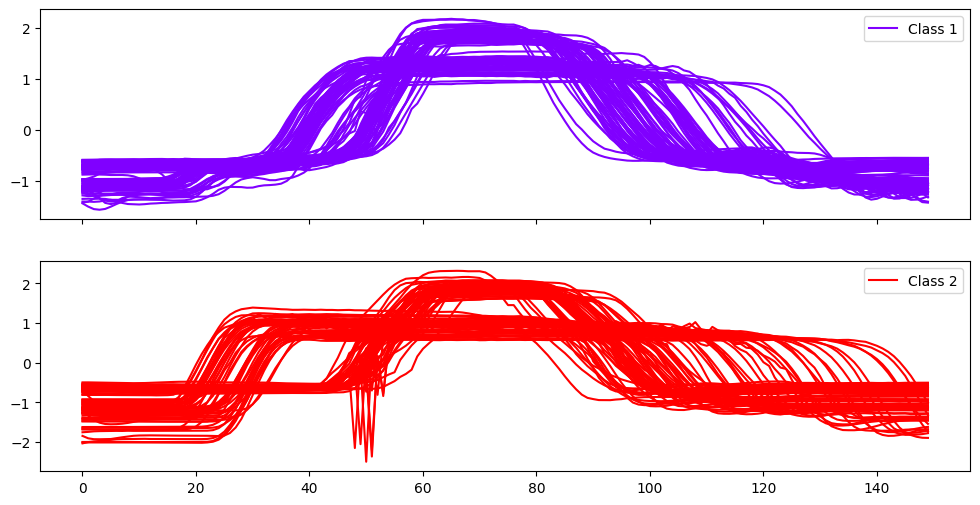

In [17]:
from aeon.visualisation import plot_collection_by_class

plot_collection_by_class(X[:,0,:], y)

# Distance-based 

In [4]:
from sklearn.metrics import accuracy_score
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier

In [4]:
y = y.astype(int)

train_size = X.shape[0] * 0.8
X_train, X_test = X[:int(train_size),0,:], X[int(train_size):,0,:]
y_train, y_test = y[:int(train_size)], y[int(train_size):]

## Классифакация

In [12]:
knn_aeon_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=5, distance='dtw')
knn_aeon_dtw.fit(X_train, y_train)
predictions_dtw = knn_aeon_dtw.predict(X_test)

accuracy = accuracy_score(y_test, predictions_dtw)
print(f"Accuracy of 1-NN (aeon) with DTW is {accuracy}")

Accuracy of 1-NN (aeon) with DTW is 0.925


In [13]:
knn_aeon_adtw = KNeighborsTimeSeriesClassifier(n_neighbors=5, distance='adtw')
knn_aeon_adtw.fit(X_train, y_train)
predictions_adtw = knn_aeon_adtw.predict(X_test)

accuracy = accuracy_score(y_test, predictions_adtw)
print(f"Accuracy of 1-NN (aeon) with ADTW is {accuracy}")

Accuracy of 1-NN (aeon) with ADTW is 0.975


In [14]:
knn_aeon_wddtw = KNeighborsTimeSeriesClassifier(n_neighbors=5, distance='wddtw')
knn_aeon_wddtw.fit(X_train, y_train)
predictions_wddtw = knn_aeon_wddtw.predict(X_test)

accuracy = accuracy_score(y_test, predictions_wddtw)
print(f"Accuracy of 1-NN (aeon) with WDDTW is {accuracy}")

Accuracy of 1-NN (aeon) with WDDTW is 1.0


## Регрессия

In [15]:
from aeon.regression.distance_based import KNeighborsTimeSeriesRegressor

In [16]:
knn_aeon_twe = KNeighborsTimeSeriesRegressor(
    n_neighbors=1,
    distance="twe",
    distance_params={"window": 0.1}
)
knn_aeon_twe.fit(X_train, y_train)
predictions_twe = knn_aeon_twe.predict(X_test)

accuracy = accuracy_score(y_test, predictions_twe)
print(f"Accuracy of 1-NN (aeon) with TWE is {accuracy}")

Accuracy of 1-NN (aeon) with TWE is 1.0


In [17]:
knn_aeon_msm = KNeighborsTimeSeriesRegressor(
    n_neighbors=1,
    distance="msm",
    distance_params={"window": 0.1}
)
knn_aeon_msm.fit(X_train, y_train)
predictions_msm = knn_aeon_msm.predict(X_test)

accuracy = accuracy_score(y_test, predictions_msm)
print(f"Accuracy of 1-NN (aeon) with MSM is {accuracy}")

Accuracy of 1-NN (aeon) with MSM is 0.95


In [18]:
knn_aeon_erp = KNeighborsTimeSeriesRegressor(
    n_neighbors=1,
    distance="erp",
    distance_params={"window": 0.1}
)
knn_aeon_erp.fit(X_train, y_train)
predictions_erp = knn_aeon_erp.predict(X_test)

accuracy = accuracy_score(y_test, predictions_erp)
print(f"Accuracy of 1-NN (aeon) with ERP is {accuracy}")

Accuracy of 1-NN (aeon) with ERP is 0.975


# Свертки

## Классификация многомерных временных рядов

In [19]:
from aeon.classification.convolution_based import RocketClassifier

classifier = RocketClassifier( n_jobs=-1, random_state=42)
classifier.fit(X_train, y_train)
classifier.score(X_test, y_test)

/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс В

1.0

In [20]:
from aeon.classification.convolution_based import  HydraClassifier

hydra = HydraClassifier(n_jobs=-1, random_state=42)
hydra.fit(X_train, y_train)
hydra.score(X_test, y_test)

/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс В

1.0

In [21]:
from aeon.classification.convolution_based import  MultiRocketHydraClassifier

classifier = MultiRocketHydraClassifier( n_jobs=-1, random_state=42)
classifier.fit(X_train, y_train)
classifier.score(X_test, y_test)

/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс В

1.0

## Регрессия

In [22]:
from aeon.regression.convolution_based import MiniRocketRegressor
from sklearn.metrics import r2_score

regressor = MiniRocketRegressor(n_jobs=-1, random_state=42)
regressor.fit(X_train, y_train)
preds = regressor.predict(X_test)
r2_score(y_test, preds)

/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс В

0.9835883148511737

In [28]:
from aeon.regression.convolution_based import HydraRegressor

regressor = HydraRegressor(n_jobs=-1, random_state=42)
regressor.fit(X_train, y_train)
preds = regressor.predict(X_test)
r2_score(y_test, preds)

/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс В

0.9735908321322138

In [29]:
from aeon.regression.convolution_based import MultiRocketHydraRegressor

regressor = MultiRocketHydraRegressor(n_jobs=-1, random_state=42)
regressor.fit(X_train, y_train)
preds = regressor.predict(X_test)
r2_score(y_test, preds)

/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс Влада/signals-ai-main/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/kirilllipin/пары/курс В

0.9786433633846391

# Feature-based

## Классификация

In [30]:
from aeon.classification.feature_based import Catch22Classifier

c22_cls = Catch22Classifier(random_state=42)
c22_cls.fit(X_train, y_train)
c22_preds_c = c22_cls.predict(X_test)
accuracy_score(y_test, c22_preds_c)

1.0

In [36]:
from aeon.classification.sklearn import RotationForestClassifier

c22_rfc = Catch22Classifier(
    estimator=RotationForestClassifier(),
    random_state=42
)
c22_rfc.fit(X_train, y_train)
c22_preds_rfc = c22_rfc.predict(X_test)
accuracy_score(y_test, c22_preds_rfc)

1.0

In [35]:
from aeon.classification.sklearn import RotationForestClassifier

c22_rfcf = Catch22Classifier(
    features=['DN_HistogramMode_5',
 'DN_HistogramMode_10',
 'CO_f1ecac',
 'CO_FirstMin_ac',
 'CO_HistogramAMI_even_2_5',
 'CO_trev_1_num',
 'MD_hrv_classic_pnn40',
 'SB_BinaryStats_mean_longstretch1',
 'SB_TransitionMatrix_3ac_sumdiagcov',
 'PD_PeriodicityWang_th0_01'],
    estimator=RotationForestClassifier(),
    random_state=42,
)
c22_rfcf.fit(X_train, y_train)
c22_preds_rfcf = c22_rfcf.predict(X_test)
accuracy_score(y_test, c22_preds_rfcf)

0.9

## Регрессия

In [39]:
from aeon.regression.feature_based import Catch22Regressor
from sklearn.metrics import mean_squared_error

c22_reg = Catch22Regressor(random_state=42)
c22_reg.fit(X_train, y_train)
c22_preds_r = c22_reg.predict(X_test)
mean_squared_error(y_test, c22_preds_r)

0.022437500000000006

In [ ]:
from aeon.regression.sklearn import RotationForestRegressor
from sklearn.metrics import mean_squared_error

c22_rfr = Catch22Regressor(estimator=RotationForestRegressor(), random_state=42)
c22_rfr.fit(X_train, y_train)
c22_preds_rfr = c22_rfr.predict(X_test)
mean_squared_error(y_test, c22_preds_rfr)

0.022294374999999998

In [42]:
from aeon.regression.sklearn import RotationForestRegressor
from sklearn.metrics import mean_squared_error

c22_rfrf = Catch22Regressor(features=['DN_HistogramMode_5',
 'DN_HistogramMode_10',
 'CO_f1ecac',
 'CO_FirstMin_ac',
 'CO_HistogramAMI_even_2_5',
 'CO_trev_1_num',
 'MD_hrv_classic_pnn40',
 'SB_BinaryStats_mean_longstretch1',
 'SB_TransitionMatrix_3ac_sumdiagcov',
 'PD_PeriodicityWang_th0_01'], estimator=RotationForestRegressor(), random_state=42)
c22_rfrf.fit(X_train, y_train)
c22_preds_rfrf = c22_rfrf.predict(X_test)
mean_squared_error(y_test, c22_preds_rfrf)

0.05973687500000001

# Deep Learning

## Классификация

Нормализация данных

In [5]:
X_train_c = (X_train - X_train.mean(axis=-1, keepdims=True)) / (X_train.std(axis=-1, keepdims=True))
X_test_c = (X_test - X_test.mean(axis=-1, keepdims=True)) / (X_test.std(axis=-1, keepdims=True))

print("Train shape:", X_train_c.shape)
print("Test shape:", X_test_c.shape)

Train shape: (160, 150)
Test shape: (40, 150)


(<Figure size 1200x600 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

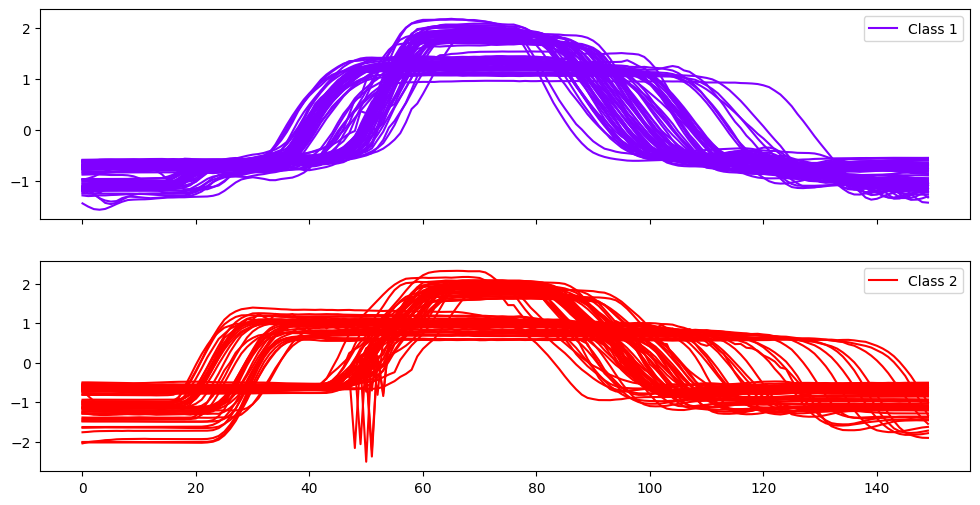

In [6]:
from aeon.visualisation import plot_collection_by_class

plot_collection_by_class(X_train_c[:,:], y_train)

In [ ]:
from aeon.classification.deep_learning import MLPClassifier

mlp_cls = MLPClassifier(n_epochs=100, random_state=42)
mlp_cls.fit(X_train_c, y_train.astype("str"))
mlp_cls_preds = mlp_cls.predict(X_test_c)
print(accuracy_score(y_test, mlp_cls_preds))

In [ ]:
from aeon.classification.deep_learning import FCNClassifier

cnn_cls = FCNClassifier(n_epochs=500, verbose=True, save_best_model=True, best_file_name="best_cnn")
cnn_cls.fit(X_train_c, y_train)
cnn_cls_preds = cnn_cls.predict(X_test_c)
print(accuracy_score(y_test, cnn_cls_preds))

In [ ]:
from aeon.classification.deep_learning import  TimeCNNClassifier

cnn_cls = TimeCNNClassifier(n_epochs=500, verbose=True, save_best_model=True, best_file_name="best_time_cnn")
cnn_cls.fit(X_train_c, y_train)
cnn_cls_preds = cnn_cls.predict(X_test_c)
print(accuracy_score(y_test, cnn_cls_preds))

## Регрессия 

In [7]:
X_train_r = (X_train - X_train.mean(axis=-1, keepdims=True)) / (X_train.std(axis=-1, keepdims=True))
X_test_r = (X_test - X_test.mean(axis=-1, keepdims=True)) / (X_test.std(axis=-1, keepdims=True))

print("Train shape:", X_train_r.shape)
print("Test shape:", X_test_r.shape)

Train shape: (160, 150)
Test shape: (40, 150)


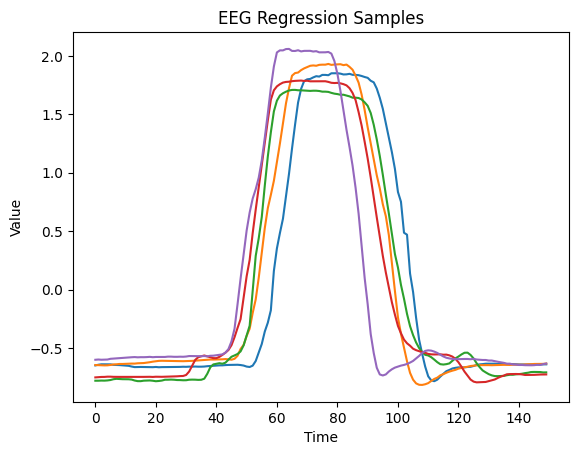

In [9]:
from matplotlib import pyplot as plt

plt.plot(X_train_r[:5,:].T)
plt.title("EEG Regression Samples")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [1]:
from aeon.regression.deep_learning import MLPRegressor
from sklearn.metrics import mean_squared_error

mlp_rgs = MLPRegressor(n_epochs=500)
mlp_rgs.fit(X_train_r, y_train)
mlp_rgs_preds = mlp_rgs.predict(X_test_r)
print(mean_squared_error(y_test, mlp_rgs_preds))

ModuleNotFoundError: str requires python version to be <3.13, but system python version is 3.13.5 (v3.13.5:6cb20a219a8, Jun 11 2025, 12:23:45) [Clang 16.0.0 (clang-1600.0.26.6)].

In [1]:
from aeon.regression.deep_learning import FCNRegressor
from sklearn.metrics import mean_squared_error

cnn_rgs = FCNRegressor(n_epochs=500)
cnn_rgs.fit(X_train_r, y_train)
cnn_rgs_preds = cnn_rgs.predict(X_test_r)
print(mean_squared_error(y_test, cnn_rgs_preds))

ModuleNotFoundError: No module named 'aeon'

In [ ]:
from aeon.regression.deep_learning import  TimeCNNRegressor
from sklearn.metrics import mean_squared_error

cnn_rgs = TimeCNNRegressor(n_epochs=500)
cnn_rgs.fit(X_train_r, y_train)
cnn_rgs_preds = cnn_rgs.predict(X_test_r)
print(mean_squared_error(y_test, cnn_rgs_preds))

plot_scatter_predictions(y_test, cnn_rgs_preds, title="TimeCNNRegressor Predictions")